## 

## Lang Graph 
### Graph
- LangGraph의 그래프는 구글의 프리겔에서 영감을 받은 슈퍼스텝방식으로 동작한다. 
- 슈퍼스텝은 그래프의 처리 과정의 한 단계로 각 노드가 병렬로 동시에 작업을 수행하는 단위이다.
- 동시에 실행되는 노드는 슈퍼스텝에 속하며 순차적으로 실행되는 노드는 별도의 슈퍼스텝에 속한다.
- 노드는 하나 이상의 입력 엣지에서 새로운 메시지를 수신할 때 활성화 된다. 활성화된 노드는 자신의 기능을 실행하고 처리 결과를 다른 노드로 전달한다. 
- 각 슈퍼스텝이 끝날 때 입력 메시지가 없는 노드는 비활성화로 표시하여 완료된 상태로 표시한다. 
- 모든 노드가 비활성화 되면 더 이상 메시지가 전송되지 않은 상태가 되면 그래프 실행이 종료된다.
  
### State
- 그래프를 정의할 때 가장 먼저 선행되어야 하는 것은 그래프의 상태를 정의하는 것이다. 
- 상태란 애플리케이션 내에서 메시지로 주고 받는 변수들의 집합이다. 
- 상태는 그래프 내 모든 노드와 엣지의 입력으로 사용되며 각 노드는 상태를 업데이트 할 수 있다. 

### Node 
- 그래프에서 노드는 실제 작업을 수행하는 실행 단위다. 
- 에이전트의 로직을 담은 파이썬 함수가 곧 노드가 되며 그래프에서 노드는 상태를 입력으로 받아 동작하고 그 결과로 상태값을 업데이트 하여 반환한다. 
- 노드는 첫번째 인자로 상태값을 두번째 인자로 설정값을 받는다. 

In [7]:
from typing import TypedDict, Annotated 
from operator import add 

class State(TypedDict):
    count: int 
    messages: Annotated[list[str], add] 
    
state = State({
    "count": 1,
    "messages": ["hello"]
})


state["messages"].append("world")
print(state)


{'count': 1, 'messages': ['hello', 'world']}


In [3]:
from langchain_core.runnables import RunnableConfig 
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages 

# 상태 그래프 선언 
builder = StateGraph(dict)

# 노드로 사용할 함수 정의 
def my_node(state: dict, config: RunnableConfig):
    print("In node", config["configurable"]["user_id"])
    return {"results" : f"Hello {state['input']}!"}


def my_other_node(state: dict):
    return state

builder.add_node("my_node", my_node) 
builder.add_node("other_node", my_other_node)


In [8]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [9]:
from langchain_openai import ChatOpenAI 

llm = ChatOpenAI(
        model="gemma-3-4b-it",
        base_url="http://localhost:1234/v1",
        api_key="lm-studio",
        temperature=0.2
        )


def chatbot(state: State):
    return {"messages" : [llm.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

In [10]:
while True:
    user_input = input("User : ")
    
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Good bye!")
        break 
    
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant ", value["messages"][-1].content)

Assistant  안녕하세요! 😊 만나서 반갑습니다. 저는 궁금한 점에 답해 드리고, 대화를 나누고, 필요한 정보를 찾아 드릴 수 있는 AI예요.

혹시 저에게 궁금한 것이 있으신가요? 아니면 그냥 편하게 이야기 나누고 싶으신가요? 말씀해주세요! 😄
Good bye!


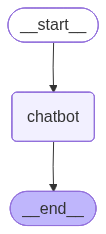

In [11]:
from IPython.display import Image, display 
display(Image(graph.get_graph().draw_mermaid_png()))


#### SearxSearchWrapper 

In [12]:
from langchain_community.utilities import SearxSearchWrapper 
from langchain_core.tools import Tool
import time 

# search = SearxSearchWrapper(
#     searx_host="http://localhost:8080"
# )

# tool = Tool(
#     name="search",
#     description="Search the web",
#     func=search.run
# )

# tools = [tool] 
# start = time.perf_counter()
# print(tool.invoke("2026년 7월 10일 서울 날씨는?"))
# end = time.perf_counter()
# print(f"실행 시간: {end - start:.4f}초")

/var/folders/kc/qm9ykcl12cv910wgvjsx9hs40000gn/T/ipykernel_86896/4012902951.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SearxSearchWrapper


#### DuckDuckgo

In [15]:
from langchain_community.tools import DuckDuckGoSearchRun

tools = []
tool = DuckDuckGoSearchRun()
start = time.perf_counter()
print(tool.invoke("오늘 서울 날씨는?"))
end = time.perf_counter()
print(f"실행 시간: {end - start:.4f}초")

tools.append(tool)

May 7, 2026 - 안팎 * 예상 강수량(10일)- (수도권) 서해5도: 20~60mm/ 서울.인천.경기: 5~40mm- (강원도) 강원내륙.산지: 5~40mm ... 11시 발표 : 오늘의 최저기온은 03시~09시 사이에 관측된 아침 최저기온이며, ... 19 minutes ago - 대한민국 24시간 뉴스 방송채널, 실시간 속보 및 제보하기, 날씨 March 12, 2026 - Current Seoul weather condition is Sunny with real-time temperature (11°C), humidity 47%, wind 6.5km/h, pressure (1028mb), UV (3.4), visibility (9km) in Seoul. 현재위치 우선: PC브라우저의 위치정보나 스마트폰의 GPS정보로 현위치를 확인하여 표출합니다. 관심지역 우선: 관심지역으로 추가된 지점을 우선 표출합니다. 위치 미확인: 브라우저에서 위치확인을 요청하지 않습니다. 조회한 지역이 없을 경우 기상청 서울청사 위치를 보여줍니다. April 15, 2026 - [보도자료] 수도권기상청-서울시, 극한기상 대응 협력 강화를 위한 기상기후 정책대응협의회 개최 2026/04/07
실행 시간: 2.0583초


In [16]:
from typing import Annotated 

from langchain_openai import ChatOpenAI 
from typing_extensions import TypedDict 
from langgraph.graph import StateGraph, START 
from langgraph.graph.message import add_messages 

class State(TypedDict):
    messages : Annotated[list, add_messages]
    

graph_builder = StateGraph(State) 

llm = ChatOpenAI(
    base_url="http://localhost:1234/v1",
    api_key="lm-studio", 
    model = "gemma-4-eb"
)

llm_with_tools = llm.bind_tools(tools)

def chatbot(state : State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)



In [17]:
import json 

from langchain_core.messages import ToolMessage 

class BasicToolNode:
    
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}
        
    
    def __call__(self, inputs : dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")

        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result, ensure_ascii=False),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}
    
tool_node = BasicToolNode(tools=[tool])

In [18]:
graph_builder.add_node("tools", tool_node)

In [19]:
from typing import Literal 

def route_tools(state : State) -> Literal["tools", "__end__"]:
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1] 
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"

graph_builder.add_conditional_edges(
    "chatbot", 
    route_tools, 
    {"tools": "tools", "__end__": "__end__"}
)

In [20]:
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

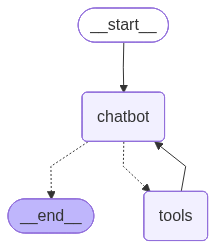

In [21]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
from langchain_core.messages import BaseMessage 

while True:
    user_input =  input("User: ")
    print("User : ", user_input)
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
        
    events = graph.stream(input={"messages": [("user", user_input)]}, stream_mode="updates")
    
    for event in events:
        for value in event.values():
            if isinstance(value["messages"][-1], BaseMessage):
                print(value)
                print("Assistant:", value["messages"][-1].content)

User :  오늘 서울 날씨
{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 96, 'total_tokens': 185, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 66, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'google/gemma-4-e4b', 'system_fingerprint': 'google/gemma-4-e4b', 'id': 'chatcmpl-louz79khemhdlaeu126v8m', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f44cf-cabd-74b3-802a-dbc3206d8552-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': '오늘 서울 날씨'}, 'id': '865157428', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 89, 'total_tokens': 185, 'input_token_details': {}, 'output_token_details': {'reasoning': 66}})]}
Assistant: 
{'messages': [ToolMessage(content='"서울 (Seoul)의 실시간 기온, 시간별 예보, 7~14일 장기 날